In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

In [2]:
dataset_name = "cifar10"

(ds_train, ds_test), info = tfds.load(
    dataset_name,
    split=["train", "test"],
    as_supervised=True,
    with_info=True
)

In [3]:
def preprocess(image, label):
    image = tf.image.resize(image, (96, 96))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [4]:
BATCH_SIZE = 8

ds_train = ds_train.map(preprocess)
ds_train = ds_train.shuffle(1000)
ds_train = ds_train.batch(BATCH_SIZE)
ds_train = ds_train.prefetch(1)   # safer than AUTOTUNE

ds_test = ds_test.map(preprocess)
ds_test = ds_test.batch(BATCH_SIZE)
ds_test = ds_test.prefetch(1)

In [5]:
encoder = tf.keras.applications.ResNet50(
    include_top=False,
    pooling="avg",
    weights="imagenet"
)

encoder.trainable = False

In [6]:
num_classes = 10

classifier = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes)
])

In [7]:
inputs = tf.keras.Input(shape=(96, 96, 3))

x = encoder(inputs, training=False)
outputs = classifier(x)

model = tf.keras.Model(inputs, outputs)

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

In [9]:
#train
model.fit(
    ds_train,
    validation_data=ds_test,
    epochs=3
)

Epoch 1/3
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 1902s 303ms/step - accuracy: 0.2156 - loss: 2.0837 - val_accuracy: 0.2728 - val_loss: 1.9401
Epoch 2/3
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 1939s 302ms/step - accuracy: 0.2732 - loss: 1.9482 - val_accuracy: 0.3149 - val_loss: 1.8755
Epoch 3/3
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 1880s 301ms/step - accuracy: 0.2939 - loss: 1.9019 - val_accuracy: 0.3338 - val_loss: 1.8234


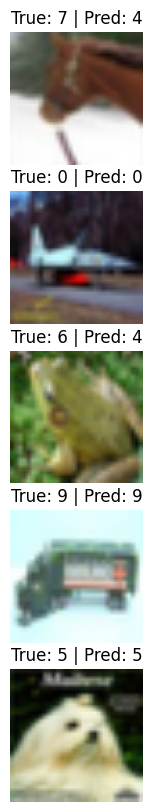

In [10]:
#sample visualization
import matplotlib.pyplot as plt
import tensorflow as tf

for images, labels in ds_test.take(1):
    preds = model(images, training=False)

    plt.figure(figsize=(10, 10))
    for i in range(5):
        plt.subplot(5, 1, i+1)
        plt.imshow(images[i].numpy())
        plt.title(
            f"True: {labels[i].numpy()} | Pred: {tf.argmax(preds[i]).numpy()}"
        )
        plt.axis("off")

    plt.show()

In [11]:
model.save("cifar10_model.h5")